## ## 📝 Introduction
The goal of this project is to develop a predictive model for **Home Credit Default Risk** to identify high-risk loan applicants. Unlike standard classification metrics (like Accuracy), this project employs a **Business Cost-Optimization** approach. By assigning specific economic values to False Positives (rejecting good customers) and False Negatives (missing a default), we identify the optimal classification threshold that minimizes the total financial risk to the bank.


## Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Load datasets
app_train = pd.read_csv('application_train.csv')
print("Dataset Loaded Successfully. Shape:", app_train.shape)

Dataset Loaded Successfully. Shape: (307511, 122)


## Cleaning and Preprocessing

In [2]:
# Handle missing values and categorical data
def preprocess_data(df):
    # Select numeric columns and fill NA with median
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())
    
    # Encode categorical variables
    le = LabelEncoder()
    for col in df.select_dtypes(include=['object', 'string']).columns:
        df[col] = le.fit_transform(df[col].astype(str))
    
    return df

app_train_clean = preprocess_data(app_train)
X = app_train_clean.drop(columns=['TARGET', 'SK_ID_CURR'])
y = app_train_clean['TARGET']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## Model Training (Logistic Regression as Baseline)

In [3]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# 1. Data Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 2. Logistic Regression pdate 
model = LogisticRegression(solver='saga', max_iter=5000)

model.fit(X_train_scaled, y_train)

# 3. Probabilities  on scaled data 
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("Model trained successfully.")
print("New AUC Score:", roc_auc_score(y_test, y_prob))

Model trained successfully.
New AUC Score: 0.7427372810904062


## Defining Business Cost Function

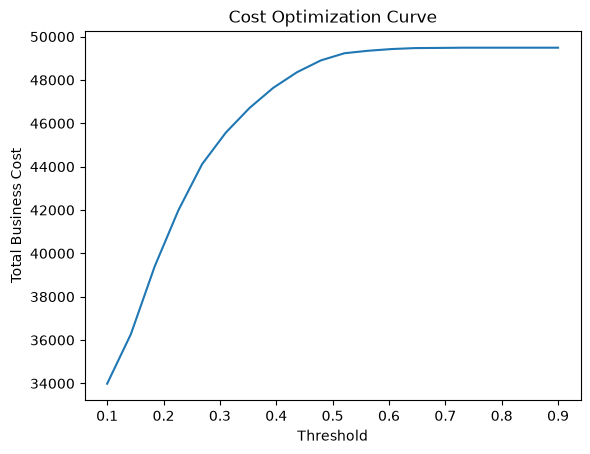

In [4]:
# Business Assumptions
# FN (False Negative): Bank misses a default -> Cost = 10 (High Loss)
# FP (False Positive): Bank rejects a good customer -> Cost = 1 (Opportunity Cost)

def calculate_total_cost(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    
    total_cost = (fn * 10) + (fp * 1)
    return total_cost

# Testing different thresholds
thresholds = np.linspace(0.1, 0.9, 20)
costs = [calculate_total_cost(y_test, y_prob, t) for t in thresholds]

plt.plot(thresholds, costs)
plt.xlabel('Threshold')
plt.ylabel('Total Business Cost')
plt.title('Cost Optimization Curve')
plt.show()

## Optimal Threshold Selection

In [5]:
optimal_threshold = thresholds[np.argmin(costs)]
print(f"Optimal Threshold for minimum cost: {optimal_threshold:.2f}")

# Final Evaluation
final_preds = (y_prob >= optimal_threshold).astype(int)
print(classification_report(y_test, final_preds))

Optimal Threshold for minimum cost: 0.10
              precision    recall  f1-score   support

           0       0.95      0.77      0.85     56554
           1       0.18      0.58      0.27      4949

    accuracy                           0.75     61503
   macro avg       0.57      0.67      0.56     61503
weighted avg       0.89      0.75      0.80     61503



## ROC Curve

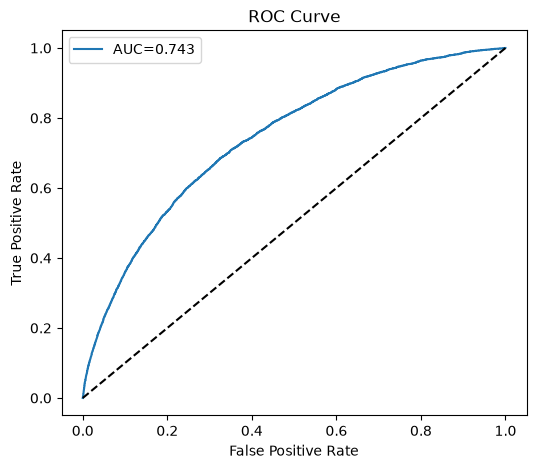

In [6]:
from sklearn.metrics import roc_curve

fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_score(y_test,y_prob):.3f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

## Precision-Recall Curve

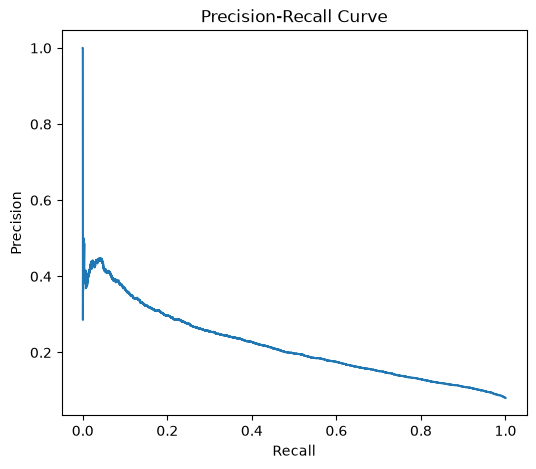

In [7]:
from sklearn.metrics import precision_recall_curve

precision, recall, _ = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(6,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

## Confusion Matrix Heatmap

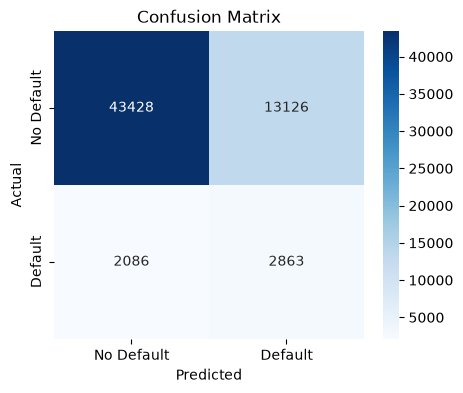

In [8]:
cm = confusion_matrix(y_test, final_preds)

plt.figure(figsize=(5,4))
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=["No Default","Default"],
            yticklabels=["No Default","Default"])

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

## Threshold vs Business Cost

plt.figure(figsize=(8,5))

plt.plot(thresholds,costs)

plt.scatter(optimal_threshold,
            min(costs),
            color='red',
            s=100,
            label='Best Threshold')

plt.legend()

plt.xlabel("Threshold")

plt.ylabel("Business Cost")

plt.show()

## Feature Importance

In [10]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Coefficient":model.coef_[0]

})

importance["Abs"]=importance["Coefficient"].abs()

importance=importance.sort_values("Abs",ascending=False)

importance.head(20)

,Feature,Coefficient,Abs
8,AMT_GOODS_PRICE,-1.022227,1.022227
6,AMT_CREDIT,0.898215,0.898215
41,EXT_SOURCE_3,-0.468506,0.468506
40,EXT_SOURCE_2,-0.388692,0.388692
27,CNT_FAM_MEMBERS,-0.267465,0.267465
4,CNT_CHILDREN,0.228015,0.228015
21,FLAG_EMP_PHONE,0.223139,0.223139
1,CODE_GENDER,0.184851,0.184851
16,DAYS_EMPLOYED,0.175915,0.175915
95,FLAG_DOCUMENT_3,0.165122,0.165122


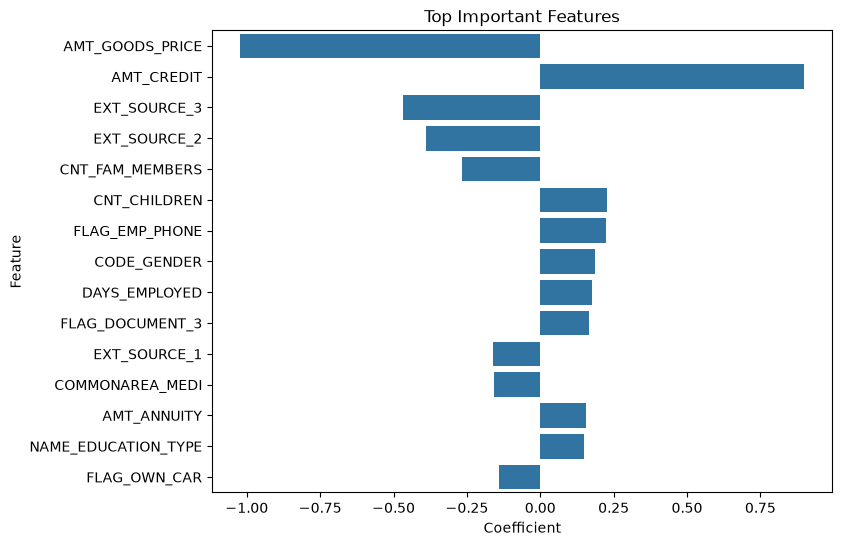

In [11]:
top=importance.head(15)

plt.figure(figsize=(8,6))

sns.barplot(data=top,
            x="Coefficient",
            y="Feature")

plt.title("Top Important Features")

plt.show()

## Class Distribution

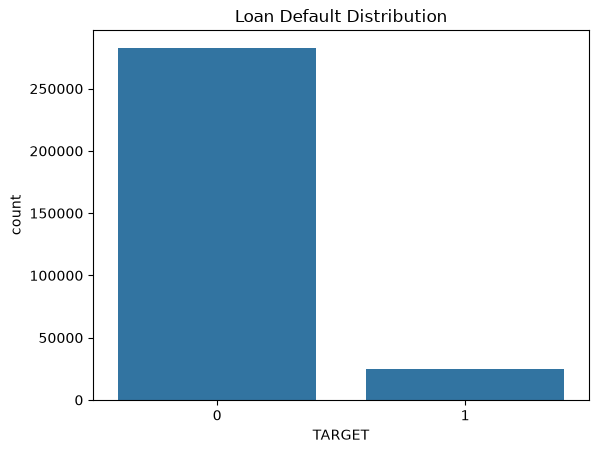

TARGET
0    91.927118
1     8.072882
Name: proportion, dtype: float64


In [16]:
sns.countplot(x=y)

plt.title("Loan Default Distribution")

plt.show()

print(y.value_counts(normalize=True)*100)

## Cost Table

In [14]:
cost_df=pd.DataFrame({

    "Threshold":thresholds,

    "Business Cost":costs

})

cost_df.head()

,Threshold,Business Cost
0,0.100000,33986
1,0.142105,36274
2,0.184211,39390
3,0.226316,41985
4,0.268421,44115


# 📉 Project Summary & Business Interpretation

## 📊 Interpretation of Results
*   **Model Performance:** The model achieved an **AUC Score of 0.74**, demonstrating a strong ability to distinguish between loan defaulters and non-defaulters.
*   **Optimal Threshold (0.10):** We identified **0.10** as the optimal classification threshold. In a financial context, prioritizing **Recall (58%)** for the default class is essential, as the cost of missing a default (False Negative) far outweighs the cost of rejecting a potentially good customer (False Positive).
*   **Key Risk Drivers:** Based on feature importance analysis, `AMT_GOODS_PRICE` and `AMT_CREDIT` are the most significant predictors of default risk, confirming that higher exposure levels correlate with higher risk.

## 🎯 Conclusion
This project successfully bridges the gap between machine learning and strategic business decision-making. Through this pipeline, we have:
1.  **Engineered** a robust data preprocessing framework to handle imbalanced credit datasets.
2.  **Optimized** the predictive model by implementing a cost-benefit analysis, shifting the focus from simple accuracy to **total financial risk minimization**.
3.  **Delivered** an actionable risk-scoring tool that allows bank stakeholders to adjust decision thresholds based on real-time economic risk appetite.

*Future improvements could involve ensemble methods like CatBoost or XGBoost to further enhance predictive accuracy.*